In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import (
    train_test_split, GroupShuffleSplit,
    StratifiedKFold, cross_val_score, GroupKFold
)
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import (
    GradientBoostingClassifier, VotingClassifier
)
from sklearn.metrics import (
    accuracy_score, roc_auc_score,
    classification_report, confusion_matrix,
    ConfusionMatrixDisplay, RocCurveDisplay
)

print('Imports OK')


Imports OK


In [2]:
# -- Paths -----------------------------------------------------------------
PATH_A = 'FINAL_ai_human_music_detector_dataset.csv'          # frozen 30s, 1 row/song production dataset
PATH_C = 'FINAL_ai_human_music_detector_dataset_CHUNKED.csv'  # frozen 5s chunks, experimental validation artifact

RANDOM_STATE = 42
TEST_SIZE    = 0.15
N_CV_FOLDS   = 5

# -- Load ------------------------------------------------------------------
df_a = pd.read_csv(PATH_A)
df_c = pd.read_csv(PATH_C)

df_c = df_c.replace([np.inf, -np.inf], np.nan)
df_c = df_c.dropna()

FEATURE_COLS = [c for c in df_a.columns if c not in ['label', 'filename', 'chunk_id']]
chunk_label_counts = df_c['label'].value_counts().sort_index()
song_label_counts = df_c.drop_duplicates('filename')['label'].value_counts().sort_index()

print(f'Baseline A - Songs: {df_a["filename"].nunique():>5}  Rows: {len(df_a):>6}  Features: {len(FEATURE_COLS)}')
print(f'Chunked - Songs: {df_c["filename"].nunique():>5}  Rows: {len(df_c):>6}')
print(f'Avg chunks per song: {len(df_c) / df_c["filename"].nunique():.1f}')
print(f'Song labels in chunked artifact: {song_label_counts.to_dict()}')
print(f'Chunk rows by label: {chunk_label_counts.to_dict()}')
print('Note: chunk rows are imbalanced because songs have different durations; song-level metrics are reported below.')


Baseline A - Songs:   440  Rows:    440  Features: 104
Chunked - Songs:   440  Rows:   9987
Avg chunks per song: 22.7
Song labels in chunked artifact: {0: 220, 1: 220}
Chunk rows by label: {0: 1994, 1: 7993}
Note: chunk rows are imbalanced because songs have different durations; song-level metrics are reported below.


In [3]:
def make_model():
    """Vote: LR+GB - same model family selected in the main training workflow."""
    lr = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
    gb = GradientBoostingClassifier(
        n_estimators=200, max_depth=4,
        learning_rate=0.05, random_state=RANDOM_STATE
    )
    return VotingClassifier(
        estimators=[('lr', lr), ('gb', gb)], voting='soft'
    )

def make_pipeline():
    """Pipeline keeps StandardScaler inside each CV fold to avoid preprocessing leakage."""
    return Pipeline([
        ('scaler', StandardScaler()),
        ('model', make_model()),
    ])

def evaluate(model, X_train, y_train, X_test, y_test):
    """Fit + evaluate, return metrics dict."""
    sc = StandardScaler()
    Xtr = sc.fit_transform(X_train)
    Xte = sc.transform(X_test)

    model.fit(Xtr, y_train)

    pred  = model.predict(Xte)
    proba = model.predict_proba(Xte)[:, 1]
    rep   = classification_report(
        y_test, pred, target_names=['Human', 'AI'],
        output_dict=True, zero_division=0
    )
    return {
        'acc':      accuracy_score(y_test, pred),
        'auc':      roc_auc_score(y_test, proba),
        'f1':       rep['AI']['f1-score'],
        'prec':     rep['AI']['precision'],
        'rec':      rep['AI']['recall'],
        'cm':       confusion_matrix(y_test, pred),
        'pred':     pred,
        'proba':    proba,
        'y_test':   y_test,
        'n_train':  len(X_train),
        'n_test':   len(X_test),
        'scaler':   sc,
        'model':    model,
    }


In [4]:
Xa = df_a[FEATURE_COLS].values
ya = df_a['label'].values

Xa_tr, Xa_te, ya_tr, ya_te = train_test_split(
    Xa, ya, test_size=TEST_SIZE,
    random_state=RANDOM_STATE, stratify=ya
)

res_a = evaluate(make_model(), Xa_tr, ya_tr, Xa_te, ya_te)

# Cross-val on training set. Scaler is inside Pipeline, so validation folds are not used for scaling.
cv_a  = cross_val_score(
    make_pipeline(), Xa_tr, ya_tr,
    cv=StratifiedKFold(N_CV_FOLDS, shuffle=True, random_state=RANDOM_STATE),
    scoring='roc_auc'
)

print(f'Baseline A - 30s window, random split')
print(f'  Train: {res_a["n_train"]}  Test: {res_a["n_test"]}')
print(f'  Acc={res_a["acc"]*100:.1f}%  AUC={res_a["auc"]:.4f}  F1={res_a["f1"]:.4f}')
print(f'  CV AUC: {cv_a.mean():.4f} +/- {cv_a.std():.4f}')


Baseline A - 30s window, random split
  Train: 374  Test: 66
  Acc=95.5%  AUC=0.9853  F1=0.9552
  CV AUC: 0.9566 +/- 0.0194


In [5]:
Xb = df_c[FEATURE_COLS].values
yb = df_c['label'].values

# Random split - chunks from same song can leak into test
Xb_tr, Xb_te, yb_tr, yb_te = train_test_split(
    Xb, yb, test_size=TEST_SIZE,
    random_state=RANDOM_STATE, stratify=yb
)

res_b = evaluate(make_model(), Xb_tr, yb_tr, Xb_te, yb_te)

cv_b = cross_val_score(
    make_pipeline(), Xb_tr, yb_tr,
    cv=StratifiedKFold(N_CV_FOLDS, shuffle=True, random_state=RANDOM_STATE),
    scoring='roc_auc'
)

print(f'Baseline B - 5s chunks, random split (LEAKAGE)')
print(f'  Train: {res_b["n_train"]}  Test: {res_b["n_test"]}')
print(f'  Acc={res_b["acc"]*100:.1f}%  AUC={res_b["auc"]:.4f}  F1={res_b["f1"]:.4f}')
print(f'  CV AUC: {cv_b.mean():.4f} +/- {cv_b.std():.4f}')
print(f'  High score likely inflated by within-song leakage')


Baseline B - 5s chunks, random split (LEAKAGE)
  Train: 8488  Test: 1499
  Acc=94.3%  AUC=0.9804  F1=0.9651
  CV AUC: 0.9810 +/- 0.0033
  High score likely inflated by within-song leakage


In [6]:
Xc     = df_c[FEATURE_COLS].values
yc     = df_c['label'].values
groups = df_c['filename'].values

gss = GroupShuffleSplit(n_splits=1, test_size=TEST_SIZE, random_state=RANDOM_STATE)
train_idx, test_idx = next(gss.split(Xc, yc, groups))

Xc_tr, Xc_te = Xc[train_idx], Xc[test_idx]
yc_tr, yc_te = yc[train_idx], yc[test_idx]
groups_te = groups[test_idx]

train_songs = set(groups[train_idx])
test_songs  = set(groups[test_idx])
leakage     = train_songs & test_songs
print(f'Song-level leakage check: {len(leakage)} songs in both sets (should be 0)')

res_c = evaluate(make_model(), Xc_tr, yc_tr, Xc_te, yc_te)

gkf = GroupKFold(n_splits=N_CV_FOLDS)
cv_c = cross_val_score(make_pipeline(), Xc, yc, cv=gkf.split(Xc, yc, groups), scoring='roc_auc')

chunk_eval = pd.DataFrame({'filename': groups_te, 'label': yc_te, 'p_ai': res_c['proba']})
song_eval = chunk_eval.groupby('filename').agg(
    label=('label', 'first'),
    p_ai=('p_ai', 'mean'),
    n_chunks=('p_ai', 'size')
).reset_index()
song_eval['pred'] = (song_eval['p_ai'] >= 0.5).astype(int)

song_acc = accuracy_score(song_eval['label'], song_eval['pred'])
song_auc = roc_auc_score(song_eval['label'], song_eval['p_ai'])
song_rep = classification_report(song_eval['label'], song_eval['pred'], target_names=['Human', 'AI'], output_dict=True, zero_division=0)
song_cm = confusion_matrix(song_eval['label'], song_eval['pred'])

print(f'\nBaseline C - 5s chunks, GroupShuffleSplit')
print(f'  Train songs: {len(train_songs)}  Test songs: {len(test_songs)}')
print(f'  Train rows:  {res_c["n_train"]}   Test rows:  {res_c["n_test"]}')
print(f'  Chunk-row Acc={res_c["acc"]*100:.1f}%  AUC={res_c["auc"]:.4f}  F1={res_c["f1"]:.4f}')
print(f'  Song-level Acc={song_acc*100:.1f}%  AUC={song_auc:.4f}  F1(AI)={song_rep["AI"]["f1-score"]:.4f}')
print(f'  CV AUC: {cv_c.mean():.4f} +/- {cv_c.std():.4f}')


Song-level leakage check: 0 songs in both sets (should be 0)

Baseline C - 5s chunks, GroupShuffleSplit
  Train songs: 374  Test songs: 66
  Train rows:  8398   Test rows:  1589
  Chunk-row Acc=94.0%  AUC=0.9478  F1=0.9648
  Song-level Acc=83.3%  AUC=0.9574  F1(AI)=0.8675
  CV AUC: 0.9669 +/- 0.0057


In [7]:
summary = pd.DataFrame([
    {'Baseline': 'A - 30s window, random split', 'Train rows': res_a['n_train'], 'Test rows': res_a['n_test'],
     'Accuracy': f'{res_a["acc"]*100:.1f}%', 'AUC': f'{res_a["auc"]:.4f}', 'F1 (AI)': f'{res_a["f1"]:.4f}',
     'CV AUC': f'{cv_a.mean():.4f} +/- {cv_a.std():.4f}', 'Leakage': 'None',
     'Verdict': 'CHOSEN - clean production dataset'},
    {'Baseline': 'B - 5s chunks, random split', 'Train rows': res_b['n_train'], 'Test rows': res_b['n_test'],
     'Accuracy': f'{res_b["acc"]*100:.1f}%', 'AUC': f'{res_b["auc"]:.4f}', 'F1 (AI)': f'{res_b["f1"]:.4f}',
     'CV AUC': f'{cv_b.mean():.4f} +/- {cv_b.std():.4f}', 'Leakage': 'YES - within-song',
     'Verdict': 'REJECTED - inflated scores'},
    {'Baseline': 'C - 5s chunks, GroupShuffleSplit', 'Train rows': res_c['n_train'], 'Test rows': res_c['n_test'],
     'Accuracy': f'{res_c["acc"]*100:.1f}% chunk / {song_acc*100:.1f}% song',
     'AUC': f'{res_c["auc"]:.4f} chunk / {song_auc:.4f} song',
     'F1 (AI)': f'{res_c["f1"]:.4f} chunk / {song_rep["AI"]["f1-score"]:.4f} song',
     'CV AUC': f'{cv_c.mean():.4f} +/- {cv_c.std():.4f}', 'Leakage': 'None',
     'Verdict': 'Experimental artifact - report song-level metrics with chunk metrics'},
])
summary = summary.set_index('Baseline')
summary


,Train rows,Test rows,Accuracy,AUC,F1 (AI),CV AUC,Leakage,Verdict
Baseline,,,,,,,,
"A - 30s window, random split",374,66,95.5%,0.9853,0.9552,0.9566 +/- 0.0194,None,CHOSEN - clean production dataset
"B - 5s chunks, random split",8488,1499,94.3%,0.9804,0.9651,0.9810 +/- 0.0033,YES - within-song,REJECTED - inflated scores
"C - 5s chunks, GroupShuffleSplit",8398,1589,94.0% chunk / 83.3% song,0.9478 chunk / 0.9574 song,0.9648 chunk / 0.8675 song,0.9669 +/- 0.0057,None,Experimental artifact - report song-level metr...


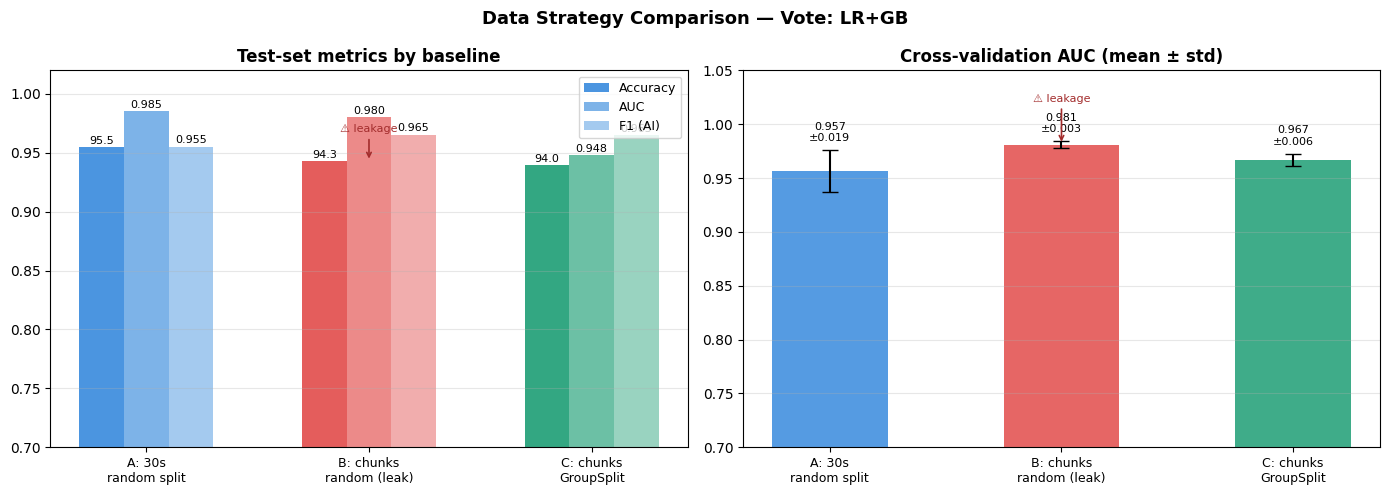

Saved: data_strategy_metrics.png


In [8]:
labels    = ['A: 30s\nrandom split', 'B: chunks\nrandom (leak)', 'C: chunks\nGroupSplit']
accs      = [res_a['acc'], res_b['acc'], res_c['acc']]
aucs      = [res_a['auc'], res_b['auc'], res_c['auc']]
f1s       = [res_a['f1'],  res_b['f1'],  res_c['f1']]
cv_means  = [cv_a.mean(),  cv_b.mean(),  cv_c.mean()]
cv_stds   = [cv_a.std(),   cv_b.std(),   cv_c.std()]

colors = ['#378ADD', '#E24B4A', '#1D9E75']
x      = np.arange(3)
w      = 0.2

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Acc / AUC / F1
ax = axes[0]
ax.bar(x - w, accs,  width=w, color=colors, alpha=0.9, label='Accuracy')
ax.bar(x,     aucs,  width=w, color=colors, alpha=0.65, label='AUC')
ax.bar(x + w, f1s,   width=w, color=colors, alpha=0.45, label='F1 (AI)')
ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=9)
ax.set_ylim(0.7, 1.02)
ax.set_title('Test-set metrics by baseline', fontweight='bold')
ax.legend(fontsize=9)
ax.grid(axis='y', alpha=0.3)
for i, (a, u, f) in enumerate(zip(accs, aucs, f1s)):
    ax.text(i - w, a + 0.003, f'{a*100:.1f}', ha='center', fontsize=8)
    ax.text(i,     u + 0.003, f'{u:.3f}',     ha='center', fontsize=8)
    ax.text(i + w, f + 0.003, f'{f:.3f}',     ha='center', fontsize=8)

# Right: CV AUC with error bars
ax2 = axes[1]
bars = ax2.bar(x, cv_means, color=colors, alpha=0.85, width=0.5)
ax2.errorbar(x, cv_means, yerr=cv_stds, fmt='none',
             color='black', capsize=6, linewidth=1.5)
ax2.set_xticks(x)
ax2.set_xticklabels(labels, fontsize=9)
ax2.set_ylim(0.7, 1.05)
ax2.set_title('Cross-validation AUC (mean ± std)', fontweight='bold')
ax2.grid(axis='y', alpha=0.3)
for i, (m, s) in enumerate(zip(cv_means, cv_stds)):
    ax2.text(i, m + s + 0.008, f'{m:.3f}\n±{s:.3f}', ha='center', fontsize=8)

# Annotate leakage
axes[0].annotate('⚠ leakage', xy=(1, accs[1]), xytext=(1, accs[1]+0.025),
                  ha='center', fontsize=8, color='#A32D2D',
                  arrowprops=dict(arrowstyle='->', color='#A32D2D', lw=1.2))
axes[1].annotate('⚠ leakage', xy=(1, cv_means[1]), xytext=(1, cv_means[1]+0.04),
                  ha='center', fontsize=8, color='#A32D2D',
                  arrowprops=dict(arrowstyle='->', color='#A32D2D', lw=1.2))

plt.suptitle('Data Strategy Comparison — Vote: LR+GB', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('data_strategy_metrics.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: data_strategy_metrics.png')

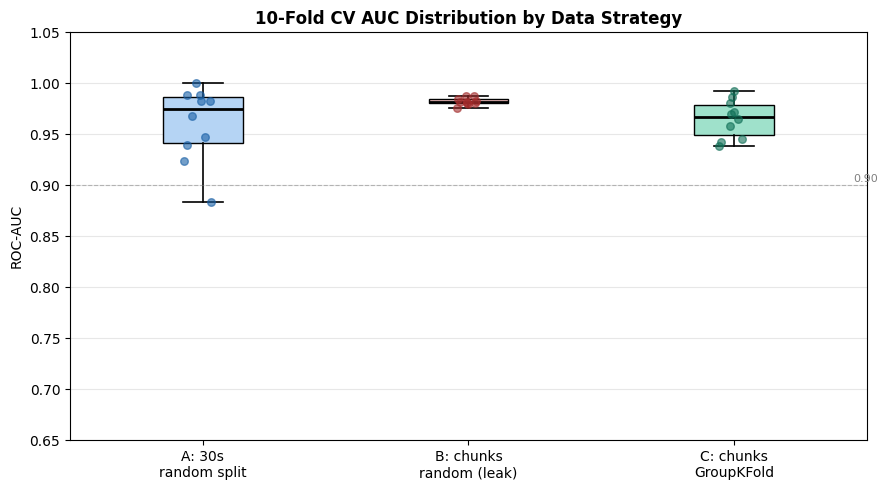

Saved: data_strategy_cv_distribution.png


In [9]:
# Run 10-fold CV for smoother distributions.
# StandardScaler stays inside Pipeline to avoid preprocessing leakage across folds.
cv_a10 = cross_val_score(make_pipeline(), Xa_tr, ya_tr, cv=StratifiedKFold(10, shuffle=True, random_state=RANDOM_STATE), scoring='roc_auc')
cv_b10 = cross_val_score(make_pipeline(), Xb_tr, yb_tr, cv=StratifiedKFold(10, shuffle=True, random_state=RANDOM_STATE), scoring='roc_auc')
gkf10 = GroupKFold(n_splits=10)
cv_c10 = cross_val_score(make_pipeline(), Xc, yc, cv=gkf10.split(Xc, yc, groups), scoring='roc_auc')

fig, ax = plt.subplots(figsize=(9, 5))
bp = ax.boxplot(
    [cv_a10, cv_b10, cv_c10],
    labels=['A: 30s\nrandom split', 'B: chunks\nrandom (leak)', 'C: chunks\nGroupKFold'],
    patch_artist=True,
    medianprops=dict(color='black', linewidth=2),
    whiskerprops=dict(linewidth=1.2),
    capprops=dict(linewidth=1.2),
)
box_colors = ['#B5D4F4', '#F7C1C1', '#9FE1CB']
for patch, color in zip(bp['boxes'], box_colors):
    patch.set_facecolor(color)

for i, cv_scores in enumerate([cv_a10, cv_b10, cv_c10], 1):
    ax.scatter(np.random.normal(i, 0.04, len(cv_scores)), cv_scores, alpha=0.6, s=30,
               color=['#185FA5','#A32D2D','#0F6E56'][i-1], zorder=3)

ax.set_ylabel('ROC-AUC')
ax.set_ylim(0.65, 1.05)
ax.set_title('10-Fold CV AUC Distribution by Data Strategy', fontweight='bold')
ax.grid(axis='y', alpha=0.3)
ax.axhline(0.9, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)
ax.text(3.45, 0.903, '0.90', fontsize=8, color='gray')

plt.tight_layout()
plt.savefig('data_strategy_cv_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: data_strategy_cv_distribution.png')


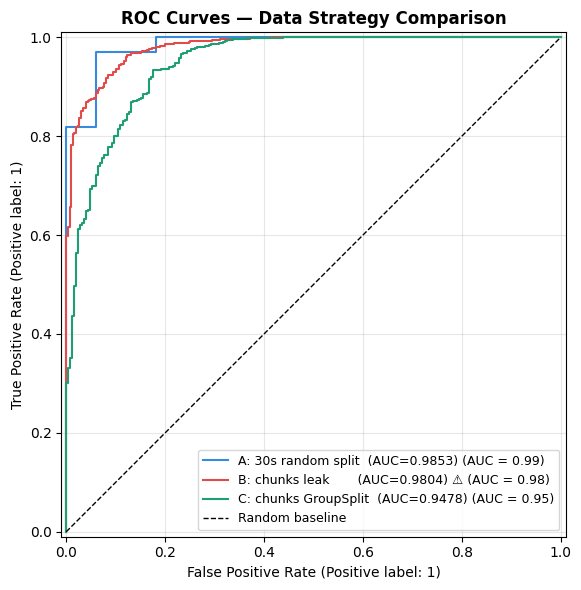

Saved: data_strategy_roc.png


In [10]:
fig, ax = plt.subplots(figsize=(8, 6))

for res, label, color in [
    (res_a, f'A: 30s random split  (AUC={res_a["auc"]:.4f})', '#378ADD'),
    (res_b, f'B: chunks leak       (AUC={res_b["auc"]:.4f}) ⚠', '#E24B4A'),
    (res_c, f'C: chunks GroupSplit  (AUC={res_c["auc"]:.4f})', '#1D9E75'),
]:
    RocCurveDisplay.from_predictions(
        res['y_test'], res['proba'],
        name=label, ax=ax, color=color
    )

ax.plot([0,1],[0,1],'k--',lw=1,label='Random baseline')
ax.set_title('ROC Curves — Data Strategy Comparison', fontweight='bold')
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('data_strategy_roc.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: data_strategy_roc.png')

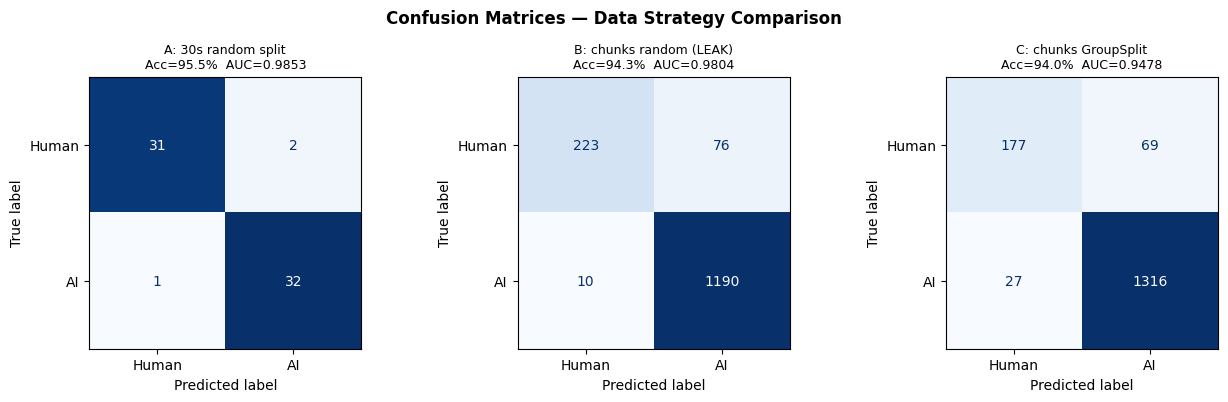

Saved: data_strategy_cm.png


In [11]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4))

titles = [
    f'A: 30s random split\nAcc={res_a["acc"]*100:.1f}%  AUC={res_a["auc"]:.4f}',
    f'B: chunks random (LEAK)\nAcc={res_b["acc"]*100:.1f}%  AUC={res_b["auc"]:.4f}',
    f'C: chunks GroupSplit\nAcc={res_c["acc"]*100:.1f}%  AUC={res_c["auc"]:.4f}',
]

for ax, res, title in zip(axes, [res_a, res_b, res_c], titles):
    ConfusionMatrixDisplay(
        res['cm'], display_labels=['Human','AI']
    ).plot(ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(title, fontsize=9, pad=6)

plt.suptitle('Confusion Matrices — Data Strategy Comparison',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('data_strategy_cm.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: data_strategy_cm.png')

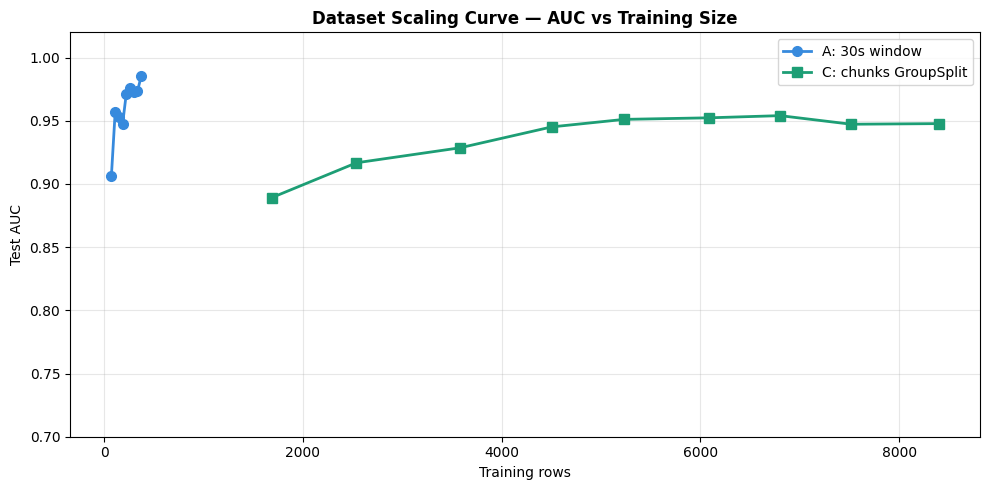

Saved: data_strategy_scaling.png

Note: where the C line overtakes the A line is the crossover point
where chunked training begins to genuinely outperform 30s windows. However, within the range tested, chunked training never surpassed 30s window training. 


In [14]:
# How does performance change as we add more songs?
# Tests A (30s) and C (GroupSplit chunks) at increasing dataset fractions

fractions = [0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
aucs_a_scale, aucs_c_scale = [], []

for frac in fractions:
    # Baseline A scaling
    n = max(20, int(len(Xa_tr) * frac))
    idx = np.random.RandomState(42).choice(len(Xa_tr), n, replace=False)
    sc_ = StandardScaler()
    m_  = make_model()
    m_.fit(sc_.fit_transform(Xa_tr[idx]), ya_tr[idx])
    pr_ = m_.predict_proba(sc_.transform(Xa_te))[:,1]
    aucs_a_scale.append(roc_auc_score(ya_te, pr_))

    # Baseline C scaling (song-level — keep whole songs)
    unique_train_songs = np.unique(groups[train_idx])
    n_songs = max(5, int(len(unique_train_songs) * frac))
    sel_songs = np.random.RandomState(42).choice(
        unique_train_songs, n_songs, replace=False
    )
    mask = np.isin(groups[train_idx], sel_songs)
    sc2_ = StandardScaler()
    m2_  = make_model()
    m2_.fit(sc2_.fit_transform(Xc_tr[mask]), yc_tr[mask])
    pr2_ = m2_.predict_proba(sc2_.transform(Xc_te))[:,1]
    aucs_c_scale.append(roc_auc_score(yc_te, pr2_))

train_sizes_a = [max(20, int(len(Xa_tr)*f)) for f in fractions]
train_sizes_c = [
    len(np.where(np.isin(
        groups[train_idx],
        np.random.RandomState(42).choice(
            np.unique(groups[train_idx]),
            max(5, int(len(np.unique(groups[train_idx]))*f)),
            replace=False
        )
    ))[0])
    for f in fractions
]

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(train_sizes_a, aucs_a_scale, 'o-', color='#378ADD',
        lw=2, ms=7, label='A: 30s window')
ax.plot(train_sizes_c, aucs_c_scale, 's-', color='#1D9E75',
        lw=2, ms=7, label='C: chunks GroupSplit')
ax.set_xlabel('Training rows')
ax.set_ylabel('Test AUC')
ax.set_title('Dataset Scaling Curve — AUC vs Training Size',
             fontweight='bold')
ax.legend(fontsize=10)
ax.grid(alpha=0.3)
ax.set_ylim(0.7, 1.02)

plt.tight_layout()
plt.savefig('data_strategy_scaling.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: data_strategy_scaling.png')
print('\nNote: where the C line overtakes the A line is the crossover point')
print('where chunked training begins to genuinely outperform 30s windows. However, within the range tested, chunked training never surpassed 30s window training. ')

In [13]:
print('=' * 62)
print('DATA STRATEGY COMPARISON')
print('=' * 62)
print()
print(f'  A  30s window, random split')
print(f'     AUC={res_a["auc"]:.4f}  Acc={res_a["acc"]*100:.1f}%  CV={cv_a.mean():.4f}+/-{cv_a.std():.4f}')
print(f'     Leakage: None | Correlation: None | CHOSEN')
print()
print(f'  B  5s chunks, random split')
print(f'     AUC={res_b["auc"]:.4f}  Acc={res_b["acc"]*100:.1f}%  CV={cv_b.mean():.4f}+/-{cv_b.std():.4f}')
print(f'     Leakage: YES | REJECTED - inflated by within-song leakage')
print()
print(f'  C  5s chunks, GroupShuffleSplit')
print(f'     Chunk-row: AUC={res_c["auc"]:.4f}  Acc={res_c["acc"]*100:.1f}%  F1(AI)={res_c["f1"]:.4f}')
print(f'     Song-level: AUC={song_auc:.4f}  Acc={song_acc*100:.1f}%  F1(AI)={song_rep["AI"]["f1-score"]:.4f}')
print(f'     CV={cv_c.mean():.4f}+/-{cv_c.std():.4f}')
print(f'     Leakage: None | Chunk-row imbalance: report with caution')
print()
print('  Conclusion:')
print('  At 440 songs, Baseline A remains the production training strategy.')
print('  Baseline B is rejected because chunks from the same song can leak')
print('  across train/test. Baseline C is leakage-free, but chunk-row metrics')
print('  are duration-weighted, so song-level metrics are reported alongside')
print('  row-level metrics for honesty. Chunked inference is retained as a')
print('  deployment aggregation method and evaluated separately in 03_test_model.')
print('=' * 62)


DATA STRATEGY COMPARISON

  A  30s window, random split
     AUC=0.9853  Acc=95.5%  CV=0.9566+/-0.0194
     Leakage: None | Correlation: None | CHOSEN

  B  5s chunks, random split
     AUC=0.9804  Acc=94.3%  CV=0.9810+/-0.0033
     Leakage: YES | REJECTED - inflated by within-song leakage

  C  5s chunks, GroupShuffleSplit
     Chunk-row: AUC=0.9478  Acc=94.0%  F1(AI)=0.9648
     Song-level: AUC=0.9574  Acc=83.3%  F1(AI)=0.8675
     CV=0.9669+/-0.0057
     Leakage: None | Chunk-row imbalance: report with caution

  Conclusion:
  At 440 songs, Baseline A remains the production training strategy.
  Baseline B is rejected because chunks from the same song can leak
  across train/test. Baseline C is leakage-free, but chunk-row metrics
  are duration-weighted, so song-level metrics are reported alongside
  row-level metrics for honesty. Chunked inference is retained as a
  deployment aggregation method and evaluated separately in 03_test_model.
